# GPU Black Hole Time-Dependent Simulation
GPU-accelerated version of the BH base (V404 Cygni-like) accretion disk simulation.
Uses `blackhole.gpu.simulation.run_simulation` which keeps all arrays GPU-resident
(or runs on CPU via NumPy when CuPy is unavailable).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from blackhole.constants import M_sun
from blackhole.gpu import is_gpu_available
from blackhole.gpu.perf_logger import PerformanceLogger
from blackhole.gpu.simulation import SimulationConfig, run_simulation

print(f"GPU available: {is_gpu_available()}")
if is_gpu_available():
    import cupy as cp
    print(f"CuPy device: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")

GPU available: True
CuPy device: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
cfg = SimulationConfig(
    M_star=9 * M_sun,
    R_1=5e8,
    R_K=2.2e11,
    R_N=4.2e11,
    M_dot=3e17,
    alpha_cold=0.04,
    alpha_hot=0.2,
    N_base=10_000,
    N_n=3,
    min_Sigma=1e-5,
    timesteps=200_001,
    output_interval=5,
    tidal_params={"cw": 0.2, "a_1": 2.2e12, "n_1": 5, "trunc_frac": 9.1 / 10},
    enable_irradiation=False,
    enable_evaporation=False,
    theta=0.5,
    use_gpu=True,
)

pl = PerformanceLogger()

t0 = time.time()
result = run_simulation(cfg, perf_logger=pl)
elapsed = time.time() - t0
print(f"Simulation complete: {len(result.t_history)} snapshots in {elapsed:.1f} s")
print(f"Total simulated time: {result.t_history[-1]:.2e} s")

Simulation complete: 40001 snapshots in 6169.8 s
Total simulated time: 1.57e+09 s


In [3]:
import os

# Read the latest run via the 'latest' pointer
latest_path = os.path.join("logs", "latest")
if os.path.islink(latest_path):
    run_name = os.readlink(latest_path)
elif os.path.isfile(latest_path):
    with open(latest_path) as f:
        run_name = f.read().strip()
else:
    run_name = None

if run_name:
    summary_path = os.path.join("logs", run_name, "summary.txt")
    print(f"Run: {run_name}\n")
    with open(summary_path) as f:
        print(f.read())
else:
    print("No profiling logs found. Run the simulation with perf_logger first.")

Run: 20260226_073410

Stage                           Total (s)   Count   Avg (ms)       %
--------------------------------------------------------------------
solve_temperature                2286.584  200001     11.433   37.1%
evolve_surface_density           2053.987  200001     10.270   33.3%
solve_scale_height                821.456  200001      4.107   13.3%
add_mass                          769.513  200001      3.848   12.5%
alpha_viscosity                    75.815  200001      0.379    1.2%
kinematic_viscosity                62.369  200001      0.312    1.0%
thermal_dt_check                   53.424  200001      0.267    0.9%
snapshot                           40.338   40000      1.008    0.7%
irradiation                         0.315  200001      0.002    0.0%
evap_setup                          0.272  200001      0.001    0.0%
--------------------------------------------------------------------
TOTAL                            6164.074



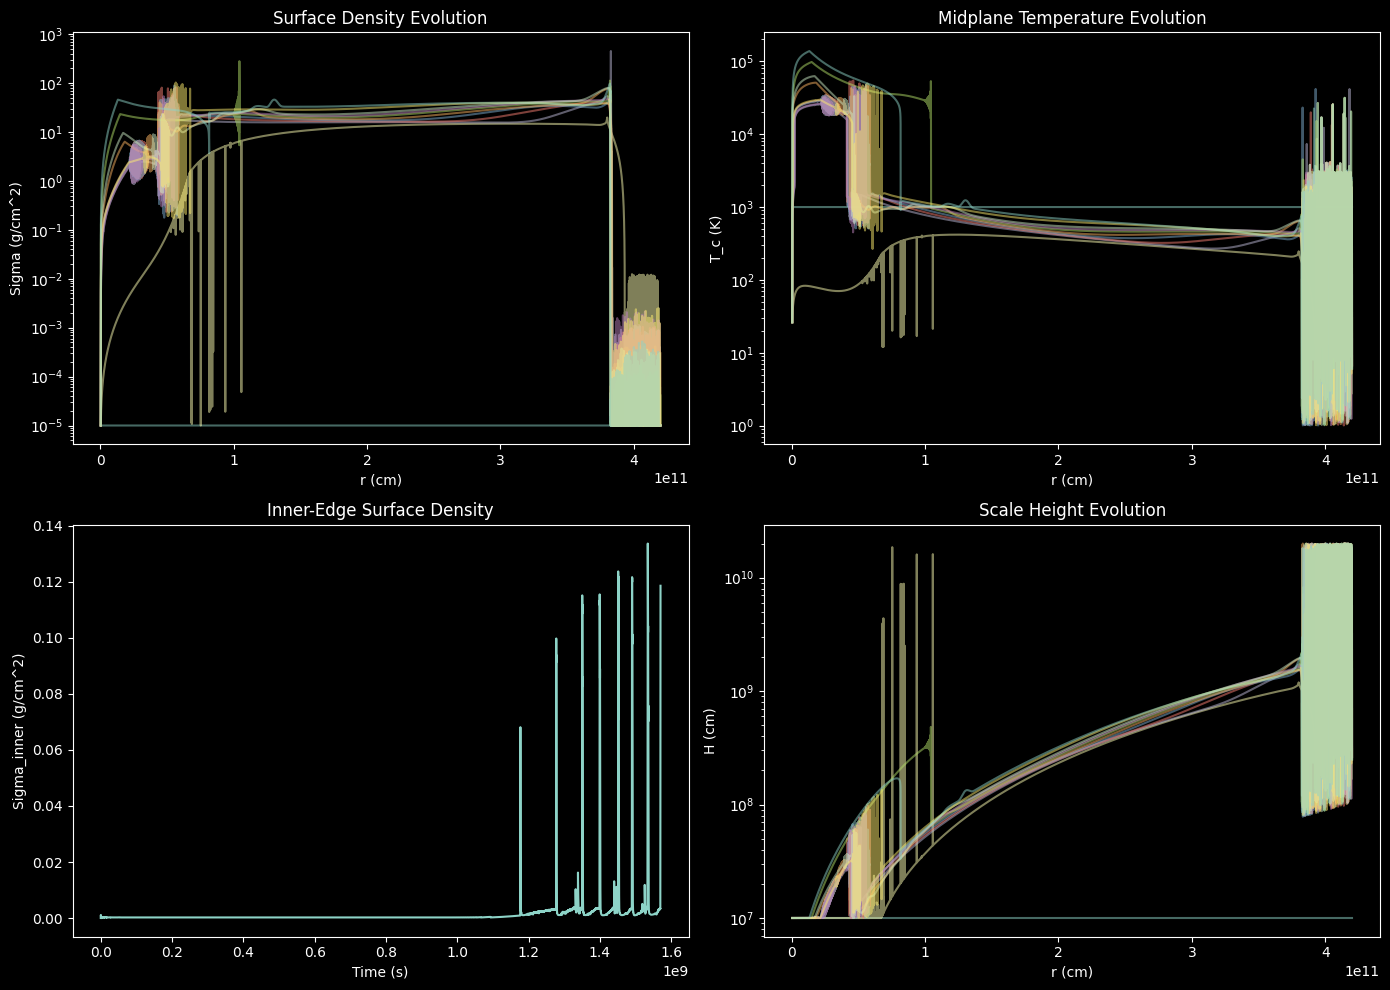

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

r_grid = np.linspace(cfg.R_1, cfg.R_N, len(result.Sigma_history[0]))

# Surface density evolution
ax = axes[0, 0]
for i in range(0, len(result.Sigma_history), max(1, len(result.Sigma_history) // 10)):
    ax.semilogy(r_grid, result.Sigma_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("Sigma (g/cm^2)")
ax.set_title("Surface Density Evolution")

# Temperature evolution
ax = axes[0, 1]
for i in range(0, len(result.Temp_history), max(1, len(result.Temp_history) // 10)):
    ax.semilogy(r_grid, result.Temp_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("T_c (K)")
ax.set_title("Midplane Temperature Evolution")

# Inner-edge Sigma vs time
ax = axes[1, 0]
ax.plot(result.t_history, result.Sigma_transfer_history)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Sigma_inner (g/cm^2)")
ax.set_title("Inner-Edge Surface Density")

# Scale height evolution
ax = axes[1, 1]
for i in range(0, len(result.H_history), max(1, len(result.H_history) // 10)):
    ax.semilogy(r_grid, result.H_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("H (cm)")
ax.set_title("Scale Height Evolution")

plt.tight_layout()
plt.show()

In [5]:
import os

DATA_DIR = "../../data"
os.makedirs(DATA_DIR, exist_ok=True)
SUFFIX = "_history_bath_array_bh_gpu.csv"

np.savetxt(f"{DATA_DIR}/Sigma{SUFFIX}", np.array(result.Sigma_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/Temp{SUFFIX}", np.array(result.Temp_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/H{SUFFIX}", np.array(result.H_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/alpha{SUFFIX}", np.array(result.alpha_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/t{SUFFIX}", np.array(result.t_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/Sigma_transfer{SUFFIX}", np.array(result.Sigma_transfer_history), delimiter=",")

print(f"Saved 6 CSV files to {DATA_DIR}/ with suffix '{SUFFIX}'")

Saved 6 CSV files to ../../data/ with suffix '_history_bath_array_bh_gpu.csv'


## Notes
- This notebook uses `blackhole.gpu.simulation.run_simulation` which orchestrates the full
  timestep loop with GPU-resident arrays (when CuPy is available).
- **Auto-dt**: the timestep ceiling is automatically computed from physics constraints
  (mass deposition limit and thermal timescale at R_K). No manual dt tuning needed —
  changing N_base, M_dot, or geometry auto-adapts the timestep.
- The `add_mass` step transfers ~824 bytes to CPU each timestep (inherently sequential).
- All other physics (diffusion, solvers, viscosity) runs on device.
- Set `use_gpu=False` to run the same orchestrator with NumPy arrays on CPU.